
# Домашнє завдання: Інтеграція Python та SQL: запити даних

Це ДЗ передбачене під виконання на локальній машині. Виконання з Google Colab буде суттєво ускладнене.

## Підготовка
1. Переконайтесь, що у вас встановлены необхідні бібліотеки:
   ```bash
   pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv
   ```

2. Створіть файл `.env` з параметрами підключення до бази даних classicmodels. Базу даних ви можете отримати через

  - docker-контейнер згідно існтрукції в [документі](https://www.notion.so/hannapylieva/Docker-1eb94835849480c9b2e7f5dc22ee4df9), також відео інструкції присутні на платформі - уроки "MySQL бази, клієнт для роботи з БД, Docker і ChatGPT для запитів" та "Як встановити Docker для роботи з базами даних без терміналу"
  - або встановивши локально цю БД - для цього перегляньте урок "Опціонально. Встановлення MySQL та  БД Сlassicmodels локально".
  
  Приклад `.env` файлу ми створювали в лекції. Ось його обовʼязкове наповнення:
    ```
    DB_HOST=your_host
    DB_PORT=3306 або 3307 - той, який Ви налаштували
    DB_USER=your_username
    DB_PASSWORD=your_password
    DB_NAME=classicmodels
    ```
  Якщо ви створили цей файл під час перегляду лекції - **новий створювати не треба**. Замініть лише назву БД, або пропишіть назву в коді створення підключення (замість отримання назви цільової БД зі змінних оточення). Але переконайтесь, що до `.env` файл лежить в тій самій папці, що і цей ноутбук.

  **УВАГА!** НЕ копіюйте скрит для **створення** `.env` файлу. В лекції він наводиться для прикладу. І давалось пояснення, що в реальних проєктах ми НІКОЛИ не пишемо доступи до бази в коді. Копіювання скрипта для створення `.env` файлу сюди в ДЗ буде вважатись грубою помилкою і ми зніматимемо бали.

3. Налаштуйте підключення через SQLAlchemy до БД за прикладом в лекції.

Рекомендую вивести (відобразити) змінну engine після створення. Вона має бути не None! Якщо None - значить у Вас не підтягнулись налаштування з .env файла.

Ви також можете налаштувати параметри підключення до БД без .env файла, просто прописавши текстом в відповідних місцях. Це - не рекомендований підхід.


In [1]:
pip install sqlalchemy pymysql pandas matplotlib seaborn python-dotenv

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import datetime
import requests
import json
import os

from dotenv import load_dotenv
import pandas as pd
import sqlalchemy as sa
from sqlalchemy import create_engine, text, MetaData, Table
from sqlalchemy.orm import sessionmaker

In [3]:
load_dotenv(override=True)

user = os.getenv('DB_USER')
password = os.getenv('DB_PASSWORD')
host = os.getenv('DB_HOST')
port = os.getenv('DB_PORT')

db = "classicmodels" 

connection_string = f"mysql+pymysql://{user}:{password}@{host}:{port}/{db}"
engine = create_engine(connection_string)

with engine.connect() as conn:
    current_db = conn.execute(text("SELECT DATABASE()")).scalar()
    print(f"✅ Зараз підключено до бази: {current_db}")

✅ Зараз підключено до бази: classicmodels


### Завдання 1: Простий запит (1 бал)

Ми працюємо з БД Classicmodels.

**Виведіть інформацію про продукти на складі** з наступними полями:
- назва продукту (productName)
- лінійка продукту (productLine)
- кількість на складі (quantityInStock)
- ціна закупки (buyPrice)

Зчитайте дані з БД з допомогою `pd.read_sql()` з SQLAlchemy engine, який ви створили на етапі підготовки.

Виведіть перші 10 продуктів, відсортованих за кількістю на складі (від більшої кількості до меншої).

In [4]:
top10_products = text("""
select productName, productLine, quantityInStock, buyPrice
from products
order by quantityInStock desc
limit 10
""")

df_filtered = pd.read_sql(
    top10_products,
    engine)

display(df_filtered)

,productName,productLine,quantityInStock,buyPrice
0,2002 Suzuki XREO,Motorcycles,9997,66.27
1,1995 Honda Civic,Classic Cars,9772,93.89
2,America West Airlines B757-200,Planes,9653,68.80
3,2002 Chevy Corvette,Classic Cars,9446,62.11
4,1932 Model A Ford J-Coupe,Vintage Cars,9354,58.48
5,1982 Ducati 996 R,Motorcycles,9241,24.14
6,1912 Ford Model T Delivery Wagon,Vintage Cars,9173,46.91
7,1976 Ford Gran Torino,Classic Cars,9127,73.49
8,1968 Dodge Charger,Classic Cars,9123,75.16
9,1965 Aston Martin DB5,Classic Cars,9042,65.96



### Завдання 2: Аналітика замовлень за 2004 рік (3 бали)

**Виведіть детальну інформацію про замовлення за 2004 рік** з наступними полями:
- Номер замовлення (orderNumber)
- Дата замовлення (orderDate)
- Статус замовлення (status)
- Ім'я клієнта (customerName)
- Країна клієнта (country)
- Загальна сума замовлення (сума всіх orderdetails.quantityOrdered * orderdetails.priceEach)

Використайте JOIN для об'єднання таблиць orders, customers, orderdetails. Додайте параметризацію за роком (тільки замовлення за 2004 рік).

Використайте `text()` та named parameters для формування запиту з SQLAlchemy.

Після отримання даних з БД проведіть обчислення з Python та напишіть висновки:
1. Побудуйте стовпчасту діаграму суми замовлень по країнам і напишіть, в якій країні найбільша сума замовлень за 2004 рік.
2. В країні з найбільшою кількістю замовлень знайдіть клієнта, який зробив замовлень на найбільшу суму і виведіть імʼя цього клієнта, на яку суму він зробив замовлень і який % від всіх замовлень в цій країні становить його сума замовлень за рік.

In [5]:
orders_2004 = text("""
select o.orderNumber, o.orderDate, o.status, c.customerName, c.country, sum(od.quantityOrdered * od.priceEach) as total_orders_sum
from orders o join customers c on o.customerNumber = c.customerNumber
join orderdetails od on o.orderNumber = od.orderNumber
where orderDate between :start_date and :end_date
group by o.orderNumber, o.orderDate, o.status, c.customerName, c.country
order by country, total_orders_sum desc
""")

start_date = datetime.date(2004, 1, 1)
end_date = datetime.date(2004, 12, 31)

df_orders_2004 = pd.read_sql(
    orders_2004,
    engine,
    params={
        'start_date': start_date,
        'end_date': end_date
    },
    parse_dates=['orderDate']
)

display(df_orders_2004)

,orderNumber,orderDate,status,customerName,country,total_orders_sum
0,10223,2004-02-20,Shipped,"Australian Collectors, Co.",Australia,44894.74
1,10347,2004-11-29,Shipped,"Australian Collectors, Co.",Australia,41995.62
2,10342,2004-11-24,Shipped,"Australian Collectors, Co.",Australia,40265.60
3,10270,2004-07-19,Shipped,Souveniers And Things Co.,Australia,35806.73
4,10361,2004-12-17,Shipped,Souveniers And Things Co.,Australia,31835.36
...,...,...,...,...,...,...
146,10236,2004-04-03,Shipped,Motor Mint Distributors Inc.,USA,5899.38
147,10290,2004-09-07,Shipped,Auto-Moto Classics Inc.,USA,5858.56
148,10294,2004-09-10,Shipped,Online Mini Collectables,USA,4424.40
149,10317,2004-11-02,Shipped,Technics Stores Inc.,USA,2434.25


Країна-лідер за сумою замовлень: USA
Сума: 1526499.65 USD


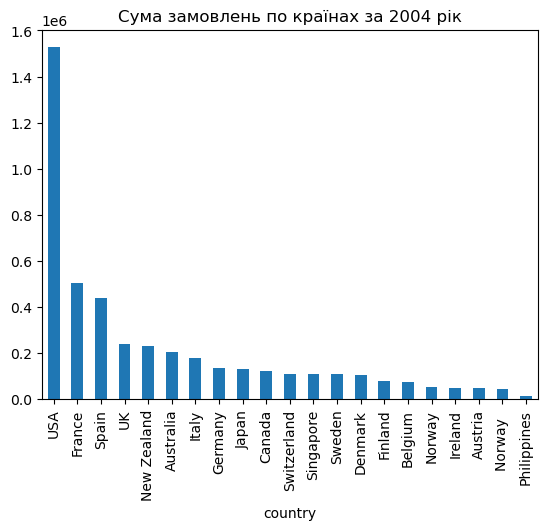

In [6]:
country_data = df_orders_2004.groupby('country')['total_orders_sum'].sum()
country_data = country_data.sort_values(ascending=False)

country_data.plot(
    kind='bar',
    title='Сума замовлень по країнах за 2004 рік'
)

top_country = country_data.idxmax()
top_sum = country_data.max()

print(f'Країна-лідер за сумою замовлень: {top_country}')
print(f'Сума: {top_sum} USD')

In [7]:
df_top_country = df_orders_2004[df_orders_2004['country'] == top_country]

total_country_sum = df_top_country['total_orders_sum'].sum()

clients_sums = df_top_country.groupby('customerName')['total_orders_sum'].sum()

top_client_name = clients_sums.idxmax()
top_client_sum = clients_sums.max()
percentage_of_total = (top_client_sum / total_country_sum) * 100

print(f'Найбільше витрачено клієнтом: {top_client_name}')
print(f'Загальна сума замовлень: {top_client_sum} USD')
print(f'Частка від усіх замовлень: {percentage_of_total:.2f}%')

Найбільше витрачено клієнтом: Mini Gifts Distributors Ltd.
Загальна сума замовлень: 231562.53 USD
Частка від усіх замовлень: 15.17%



### Завдання 3: Аналітичний запит - Топ продуктів по продажах (6 балів)

В цьому завданні ви отримуєте 1 бал за правильний SQL запит і по 1 балу за кожне завдання з Python.

**Проведіть аналіз прибутковості продуктів** та для цього дістаньте з БД інформацію з наступними полями:
- Назва продукту
- Лінійка продукту (productLine)
- Загальний дохід з цього продукту (сума quantity * priceEach)
- Ранг продукту по доходу (тобто яке місце посідає цей продукт за доходом серед усіх продуктів в нашому магазині)
- Який відсоток від загального доходу компанії складає цей продукт
- Різниця з середнім доходом по лінійці продукту (в %)

Відсортуйте дані за спаданням значень колонки "Який відсоток від загального доходу компанії складає цей продукт".

При створенні SQL запиту вам можуть стати в нагоді:
- **CTE** для розрахунку доходу по кожному продукту
- **Віконні функції** для ранжування та порівняння з середнім

Після отримання даних з БД проведіть обчислення (де треба) з Python та напишіть висновки:
1. Який відсоток від загального доходу складає ТОП1 продукт і що це за продукт?
2. Створіть стовпчикову діаграму топ-10 продуктів по доходу. В скільки разів відрізняється сумарний дохід за ТОП1 продуктом від 10го продукту за сумою доходу?
3. Створіть кругову діаграму розподілу доходу по лініях продуктів. Який відсоток від всіх продажів становлять продажі за ТОП2 лініями сумарно?
4. Розрахуйте та виведіть за принципом Парето (80/20) - скільки продуктів дають 80% доходу. Тобто нам треба знайти кількість продуктів сумарне значення "відсотку від загального доходу компанії", яких складає 80 починаючи з продукту з найбільшим цим відсотком.
5. Зробіть ще будь-яке аналітичне дослідження, яке дасть нам більше розуміння наших даних, що ми дістали в БД в цьому завданні. Сформоване питання до даних і обчислення має бути обовʼязково. Візуалізація - опціонально.

Візуалізацію можна створювати з будь-якою бібліотекою на ваш вибір.

In [11]:
product_line_analysis = text("""
with product_revenue as(
select p.productName, p.productLine, sum(od.quantityOrdered * od.priceEach) as total_revenue
from products p join orderdetails od on p.productCode = od.productCode
group by p.productName, p.productLine),
product_analysis as(
select productName, productLine, total_revenue, rank() over(order by total_revenue desc) as product_rank,
    sum(total_revenue) over() as global_total, avg(total_revenue) over(partition by productLine) as line_avg
from product_revenue
)
select productName, productLine, total_revenue, product_rank, (total_revenue/global_total) * 100 as percentage_of_revenue,
    ((total_revenue - line_avg) / line_avg) * 100 as diff_with_avg
from product_analysis
order by percentage_of_revenue desc
""")

df_product_line_analysis = pd.read_sql(product_line_analysis, engine)

display(df_product_line_analysis)

,productName,productLine,total_revenue,product_rank,percentage_of_revenue,diff_with_avg
0,1992 Ferrari 360 Spider red,Classic Cars,276839.98,1,2.882492,165.783219
1,2001 Ferrari Enzo,Classic Cars,190755.86,2,1.986173,83.137228
2,1952 Alpine Renault 1300,Classic Cars,190017.96,3,1.978490,82.428799
3,2003 Harley-Davidson Eagle Drag Bike,Motorcycles,170686.00,4,1.777203,97.865732
4,1968 Ford Mustang,Classic Cars,161531.48,5,1.681885,55.080046
...,...,...,...,...,...,...
104,1982 Ducati 996 R,Motorcycles,33268.76,105,0.346398,-61.433582
105,1958 Chevy Corvette Limited Edition,Classic Cars,31627.96,106,0.329314,-69.635235
106,1982 Lamborghini Diablo,Classic Cars,30972.87,107,0.322493,-70.264161
107,1936 Mercedes Benz 500k Roadster,Vintage Cars,29763.39,108,0.309900,-60.261604


In [13]:
top_1_product = df_product_line_analysis.iloc[0]
name = top_1_product['productName']
percent = top_1_product['percentage_of_revenue']

print(f'Топ-1 продукт:{name}')
print(f'Частка у загальному доході: {percent}%')

Топ-1 продукт:1992 Ferrari 360 Spider red
Частка у загальному доході: 2.882492%


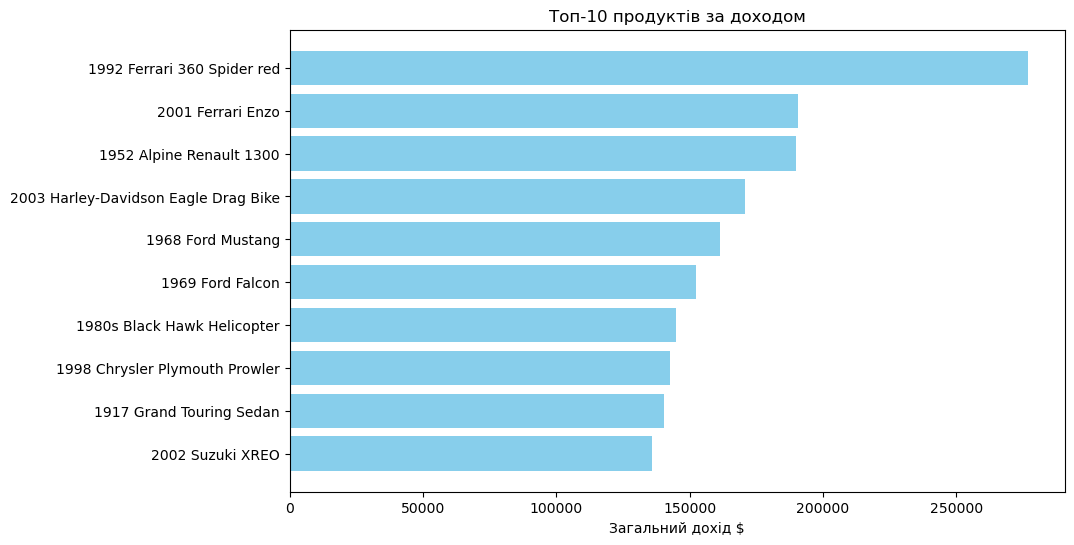

Дохід ТОП-1 продукту у 2.04 раза(и) вищий за дохід 10-го продукту.


In [18]:
import matplotlib.pyplot as plt

top_10 = df_product_line_analysis.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10['productName'][::-1], top_10['total_revenue'][::-1], color='skyblue')
plt.xlabel('Загальний дохід $')
plt.title('Топ-10 продуктів за доходом')
plt.show()

diff_ratio = top_10.iloc[0]['total_revenue'] / top_10.iloc[9]['total_revenue']
print(f"Дохід ТОП-1 продукту у {diff_ratio:.2f} раза(и) вищий за дохід 10-го продукту.")

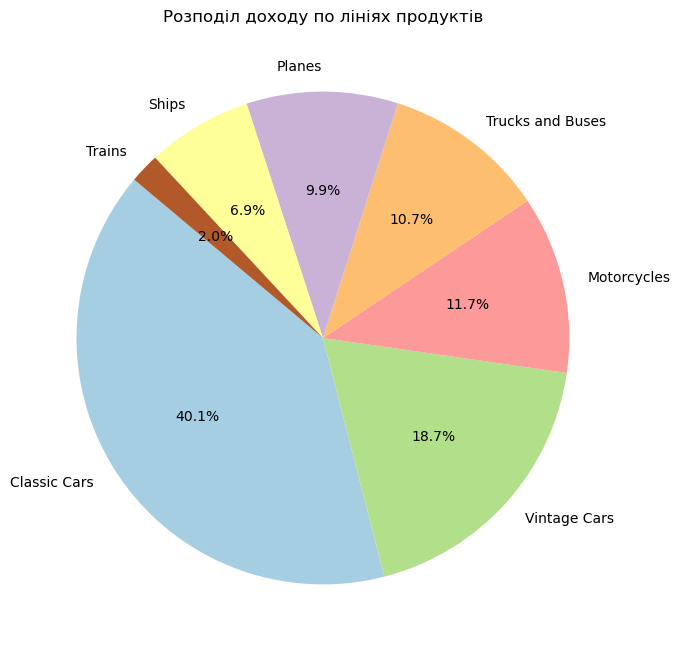

ТОП-2 лінії продуктів сумарно складають 58.84% від усіх продажів.


In [19]:
line_dist = df_product_line_analysis.groupby('productLine')['total_revenue'].sum().sort_values(ascending=False)
total_company_revenue = line_dist.sum()

plt.figure(figsize=(8, 8))
line_dist.plot(kind='pie', autopct='%1.1f%%', startangle=140, colormap='Paired')
plt.title('Розподіл доходу по лініях продуктів')
plt.ylabel('')
plt.show()

top_2_lines_share = (line_dist.head(2).sum() / total_company_revenue) * 100
print(f"ТОП-2 лінії продуктів сумарно складають {top_2_lines_share:.2f}% від усіх продажів.")

In [20]:
df_product_line_analysis['cum_percent'] = df_product_line_analysis['percentage_of_revenue'].cumsum()

pareto_products = df_product_line_analysis[df_product_line_analysis['cum_percent'] <= 80]
count_80 = len(pareto_products)
total_count = len(df_product_line_analysis)

print(f"80% доходу компанії забезпечують {count_80} продуктів (це {count_80/total_count*100:.1f}% від загальної кількості товарів).")

80% доходу компанії забезпечують 71 продуктів (це 65.1% від загальної кількості товарів).


**Який розрив у ціні між найдорожчим товаром та найдешевшим всередині кожної лінійки?**

In [23]:
product_gap = df_product_line_analysis.groupby('productLine')['total_revenue'].agg(['max', 'min', 'mean'])
product_gap['gap_ratio'] = product_gap['max'] / product_gap['min']

display(product_gap.sort_values(by='gap_ratio', ascending=False))

,max,min,mean,gap_ratio
productLine,,,,
Classic Cars,276839.98,30972.87,104160.067297,8.938144
Motorcycles,170686.00,33268.76,86263.547692,5.130519
Vintage Cars,140535.60,28052.94,74898.317917,5.009657
Planes,144959.91,42692.53,79553.128333,3.395440
Trucks and Buses,119085.25,46519.05,93101.233636,2.559924
Ships,112427.12,47550.40,73777.593333,2.364378
Trains,82617.12,52123.81,62844.306667,1.585017


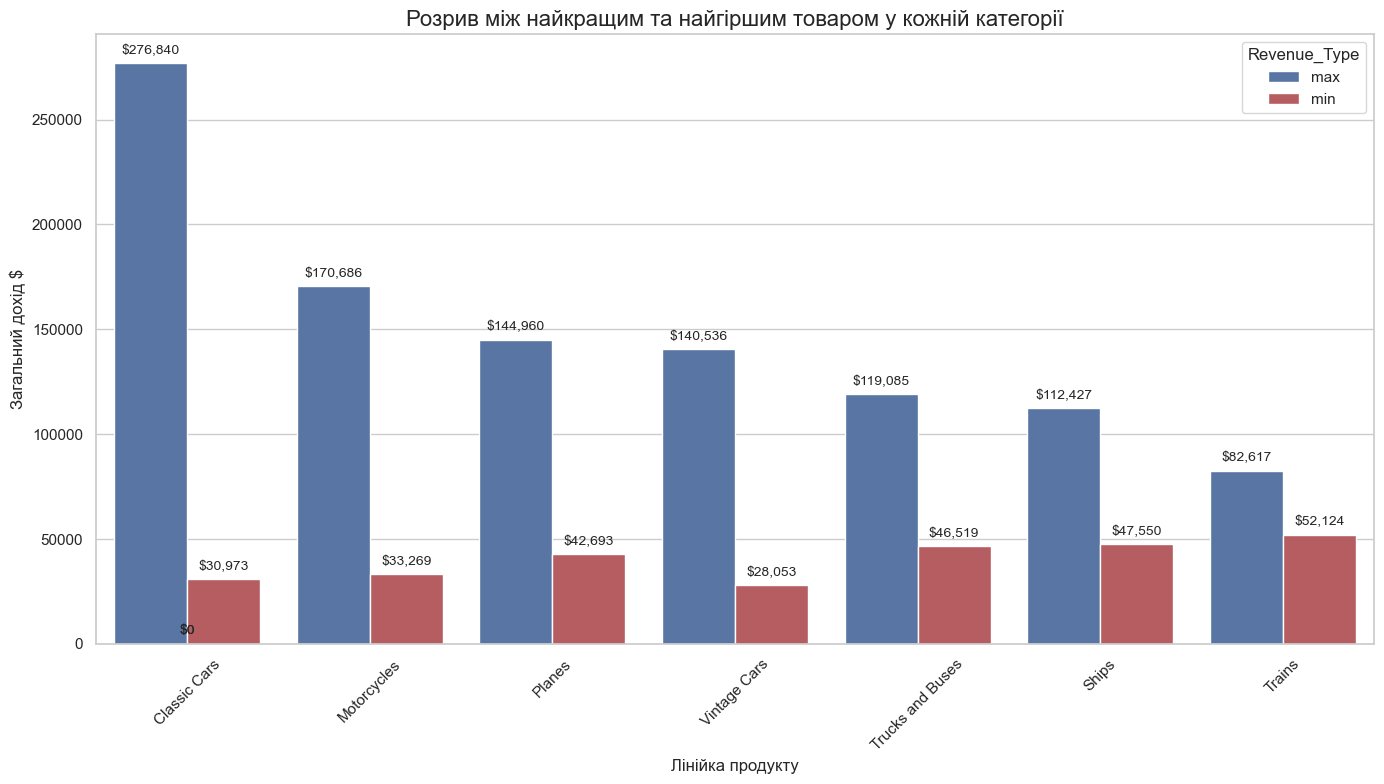

In [28]:
import seaborn as sns

df_gap_plot = product_gap.reset_index()
df_gap_plot = df_gap_plot.sort_values(by='max', ascending=False)

df_melted = pd.melt(df_gap_plot, 
                     id_vars=['productLine'],
                     value_vars=['max', 'min'],
                     var_name='Revenue_Type',
                     value_name='Revenue_Amount')

sns.set_theme(style="whitegrid")

plt.figure(figsize=(14, 8))
ax = sns.barplot(
    data=df_melted,
    x='productLine', 
    y='Revenue_Amount',
    hue='Revenue_Type',
    palette=['#4c72b0', '#c44e52']
)

plt.title('Розрив між найкращим та найгіршим товаром у кожній категорії', fontsize=16)
plt.xlabel('Лінійка продукту', fontsize=12)
plt.ylabel('Загальний дохід $', fontsize=12)
plt.xticks(rotation=45)

for p in ax.patches:
    ax.annotate(f'${p.get_height():,.0f}', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha = 'center', va = 'center', 
                xytext = (0, 9), 
                textcoords = 'offset points', 
                fontsize=10)

plt.tight_layout()
plt.show()

**Classic Cars (8.94) абсолютний лідер. Ferrari 360 Spider приносить майже в 9 разів більше доходу, ніж найменш популярна модель у цій же категорії Lamborghini Diablo.**

**Trains (1.58) найбільш збалансована категорія. Усі товари продаються приблизно однаково стабільно.**

### ОПЦІОНАЛЬНО. Завдання 4: Аналітичний запит - Динаміка продажів по місяцях (8 балів)

**Проведіть аналіз динаміки продажів по місяцях** та для цього дістаньте з бази інформацію з наступними полями:
- Рік та місяць замовлень
- Кількість замовлень за цей рік-місяць
- Загальний дохід (quantityOrdered * priceEach) за цей рік-місяць
- На який % ми зросли за доходом порівняно з попереднім місяцем
- Накопичувальний дохід до цього місяця за рік
- Ковзне середнє доходу за 3 місяці
- Ранг цього місяця за доходом

Використайте:
- **CTE** для агрегації продажів по місяцях
- **Віконні функції** для розрахунку:
  - Зростання доходу порівняно з попереднім місяцем (LAG)
  - Накопичувальний дохід за рік
  - Ковзне середнє доходу за 3 місяці (AVG OVER)
  - Ранжування місяців за доходом (RANK)

Після отримання даних з БД побудуйте наступні графіки і напишіть коротко, які висновки з них можна зробити.
1. Створіть лінійний графік доходу по місяцях. Чи є тред до зростання в даних?
2. Створіть графік місяць-до-місяця зростання у відсотках.
3. Створіть heatmap сезонності (місяць vs рік)
4. Відобразіть козвне середнє разом з динамікою продажів.
5. Розрахуйте кореляцію між кількістю замовлень та середнім чеком та побудуйте графік розсіювання між цими змінними. Чи є лінійна залежність?

Очікуваний результат кожного графіку - нижче.
В першому графіку я додала лінію тренду аби показати тренд. Вам її додавати не треба.


In [31]:
monthly_dinamic = text("""
with monthly_sales as (
select 
    year(o.orderDate) as sale_year, 
    month(o.orderDate) as sale_month, 
    count(distinct o.orderNumber) as order_count,
    sum(od.quantityOrdered * od.priceEach) as monthly_revenue
from orders o join orderdetails od 
on o.orderNumber = od.orderNumber
group by year(o.orderDate), month(o.orderDate)
),
time_analysis as (
select 
    sale_year, 
    sale_month, 
    order_count, 
    monthly_revenue, 
    lag(monthly_revenue) over (order by sale_year, sale_month) as prev_month_revenue,
    sum(monthly_revenue) over (partition by sale_year order by sale_month) as cumulative_revenue_year,
    avg(monthly_revenue) over (order by sale_year, sale_month rows between 2 preceding and current row) as rolling_avg_3m,
    rank() over(order by monthly_revenue desc) as revenue_rank
from monthly_sales
)
select 
    sale_year, 
    sale_month, 
    order_count, 
    monthly_revenue, 
    revenue_rank, 
    ((monthly_revenue - prev_month_revenue) / prev_month_revenue) * 100 as revenue_growth_pct,
    cumulative_revenue_year, 
    rolling_avg_3m, 
    concat(sale_year, '-', lpad(sale_month, 2, '0')) as period
from time_analysis
order by sale_year, sale_month
""")

df_monthly_dinamic = pd.read_sql(monthly_dinamic, engine)
display(df_monthly_dinamic)

,sale_year,sale_month,order_count,monthly_revenue,revenue_rank,revenue_growth_pct,cumulative_revenue_year,rolling_avg_3m,period
0,2003,1,5,116692.77,29,NaN,116692.77,116692.770000,2003-01
1,2003,2,3,128403.64,28,10.035643,245096.41,122548.205000,2003-02
2,2003,3,6,160517.14,26,25.009805,405613.55,135204.516667,2003-03
3,2003,4,7,185848.59,23,15.781150,591462.14,158256.456667,2003-04
4,2003,5,6,179435.55,24,-3.450680,770897.69,175267.093333,2003-05
5,2003,6,7,150470.77,27,-16.142164,921368.46,171918.303333,2003-06
6,2003,7,7,201940.36,21,34.205707,1123308.82,177282.226667,2003-07
7,2003,8,5,178257.11,25,-11.727844,1301565.93,176889.413333,2003-08
8,2003,9,8,236697.85,19,32.784521,1538263.78,205631.773333,2003-09
9,2003,10,18,514336.21,3,117.296528,2052599.99,309763.723333,2003-10


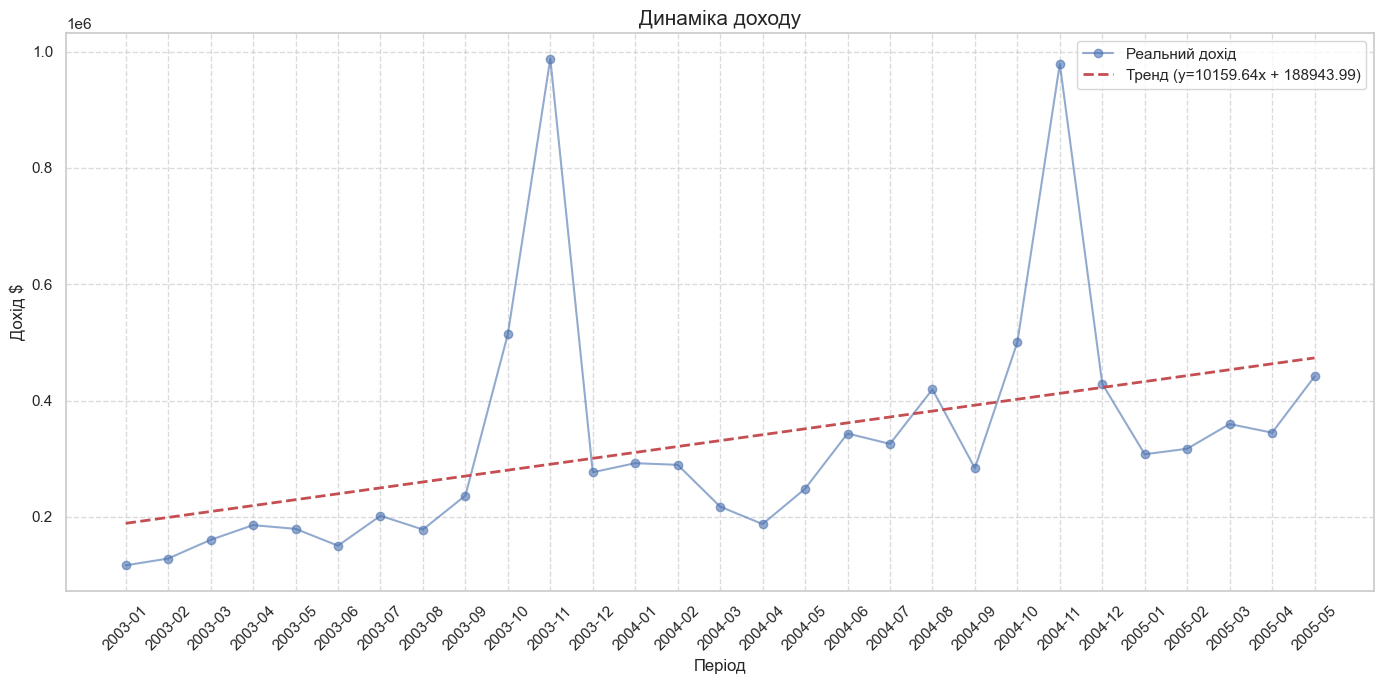

In [36]:
import numpy as np

x = np.arange(len(df_monthly_dinamic))
y = df_monthly_dinamic['monthly_revenue']

z = np.polyfit(x, y, 1)
p = np.poly1d(z)

plt.figure(figsize=(14, 7))

plt.plot(df_monthly_dinamic['period'], y, marker='o', label='Реальний дохід', alpha=0.6)

plt.plot(df_monthly_dinamic['period'], p(x), "r--", linewidth=2, label=f'Тренд (y={z[0]:.2f}x + {z[1]:.2f})')

plt.title('Динаміка доходу', fontsize=15)
plt.xlabel('Період')
plt.ylabel('Дохід $')
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Лінія тренду чітко вказує на зростання. У 2003 та 2004 роках ми бачимо сильні піки, які можуть бути пов'язані з передсвятковим сезоном.

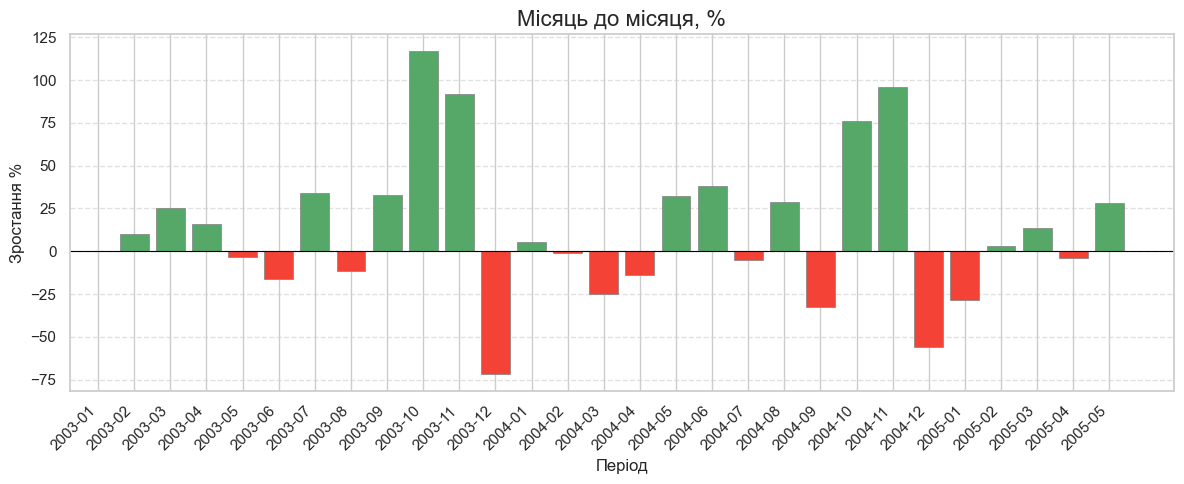

In [46]:
colors = ['#55a868' if x >= 0 else '#f44336' for x in df_monthly_dinamic['revenue_growth_pct']]

plt.figure(figsize=(12, 5))

plt.bar(
    df_monthly_dinamic['period'], 
    df_monthly_dinamic['revenue_growth_pct'], 
    color=colors, 
    edgecolor='grey',
    linewidth=0.5
)

plt.axhline(0, color='black', linewidth=0.8)

plt.title('Місяць до місяця, %', fontsize=16)
plt.ylabel('Зростання %', fontsize=12)
plt.xlabel('Період', fontsize=12)
plt.xticks(rotation=45, ha='right')

plt.grid(axis='y', linestyle='--', alpha=0.6)

plt.tight_layout()
plt.show()

Після сезонниз піків у листопаді спостерігається значне падіння, що вказує лише на корекцію після аномально високих продажів, а не на збитковість.

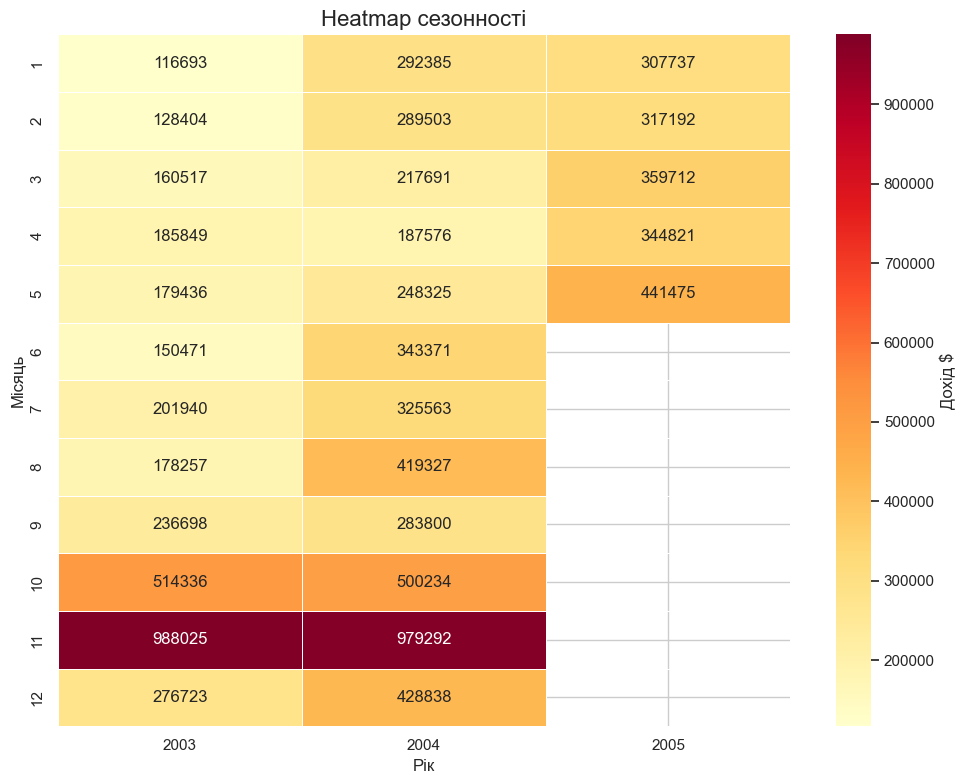

In [49]:
heatmap_data = df_monthly_dinamic.pivot(index='sale_month', columns='sale_year', values='monthly_revenue')

plt.figure(figsize=(10, 8))
sns.heatmap(
    heatmap_data, 
    annot=True,         
    fmt=".0f",         
    cmap="YlOrRd",    
    linewidths=.5,    
    cbar_kws={'label': 'Дохід $'}
)

plt.title('Heatmap сезонності', fontsize=16)
plt.xlabel('Рік', fontsize=12)
plt.ylabel('Місяць', fontsize=12)

plt.tight_layout()
plt.show()

Листопад забарвлений найтемніше, що відповідає попереднім висновкам. Колір стає темнішим і числа більшими з кожним роком, що вказує на зростання.

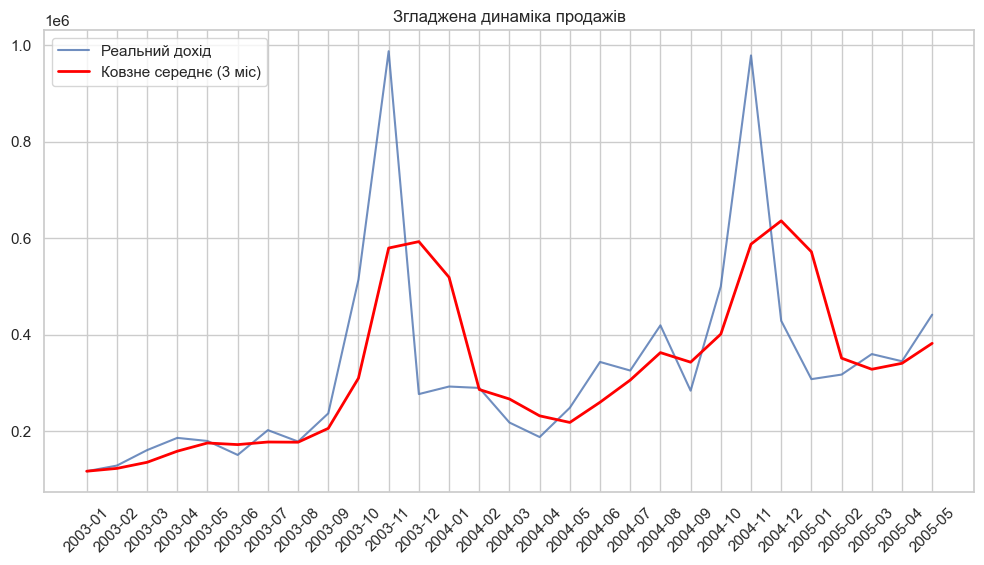

In [51]:
plt.figure(figsize=(12, 6))
plt.plot(df_monthly_dinamic['period'], df_monthly_dinamic['monthly_revenue'], alpha=0.8, label='Реальний дохід')
plt.plot(df_monthly_dinamic['period'], df_monthly_dinamic['rolling_avg_3m'], color='red', linewidth=2, label='Ковзне середнє (3 міс)')
plt.title('Згладжена динаміка продажів')
plt.xticks(rotation=45)
plt.legend()
plt.show()

Прослідковується зростаюча динаміка продажів, навіть на згладженій кривій, яка допомагає відфільтровувати зайвий "інформаційний шум".

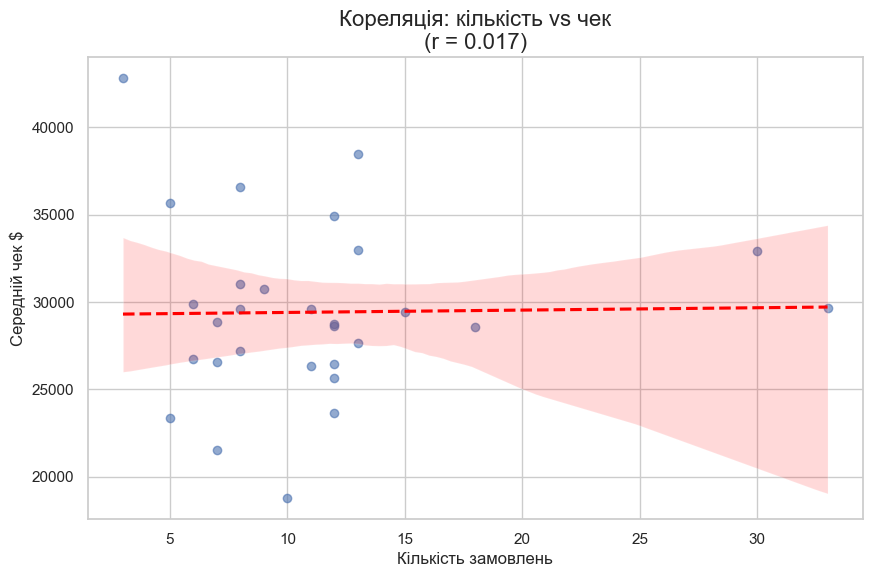

In [57]:
df_monthly_dinamic['avg_check'] = df_monthly_dinamic['monthly_revenue'] / df_monthly_dinamic['order_count']
r_value = df_monthly_dinamic['order_count'].corr(df_monthly_dinamic['avg_check'])

plt.figure(figsize=(10, 6))
sns.regplot(data=df_monthly_dinamic, x='order_count', y='avg_check', 
            scatter_kws={'alpha':0.6}, line_kws={'color':'red', 'linestyle':'--'})

plt.title(f'Кореляція: кількість vs чек\n(r = {r_value:.3f})', fontsize=16)
plt.xlabel('Кількість замовлень')
plt.ylabel('Середній чек $')
plt.show()

Є аутлаєри, але в загальному не можна сказати, що кореляція присутня.